> Imports & Phase 1 Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from cleaning_functions import clean_data

path_dir = kagglehub.dataset_download("prevek18/ames-housing-dataset")
df = clean_data(path_dir + "/AmesHousing.csv")

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset
Shape before cleaning: (2930, 82)
Number of duplicates: 0
Shape after cleaning: (2930, 82)
(2930, 82)
0
0
Shape before cleaning: (2930, 82)
Number of duplicates: 0
Shape after cleaning: (2930, 82)
Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Shape before cleaning: (2930, 82)
Number of duplicates: 0
Shape after cleaning: (2930, 82)


> One-Hot Encoding

In [3]:
def one_hot_encode(df):
    return pd.get_dummies(df, columns=["MS Zoning", "Neighborhood"], drop_first=True)
# Neighborhood and zone types affect price independently, so we convert them to binary (0 and 1).

> Ordinal Encoding

In [4]:
def ordinal_encode(df):
    qual_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
    df["Kitchen Qual Ord"] = df["Kitchen Qual"].map(qual_map).fillna(0)
    return df
# Kitchen quality has a specific order (e.g., Excellent, Good); this order is converted to ranked numbers to assist the model.

> Domain Features (Ratios)

In [5]:
def create_domain_features(df):
    df["price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, np.nan)
    df["bathroom_ratio"] = (df["Full Bath"] + 0.5 * df["Half Bath"]) / df["TotRms AbvGrd"].replace(0, np.nan)
    return df.fillna(df.median(numeric_only=True))
# Price per sqft and bathroom ratio help in comparing different properties.

> Interaction Feature

In [6]:
def create_interaction_feature(df):
    df["quality_x_area"] = df["Overall Qual"] * df["Gr Liv Area"]
    return df
# Multiplying quality by area highlights the added value for larger spaces.

> Log Transformation

In [7]:
def log_transform(df):

    # Histogram Before

    df["SalePrice"].hist(bins=30)

    plt.title("Before Log Transform")

    plt.show()



    df["SalePrice_Log"] = np.log1p(df["SalePrice"])



    # Histogram After

    df["SalePrice_Log"].hist(bins=30)

    plt.title("After Log Transform")

    plt.show()

    return df

> Binning Feature

In [8]:
def bin_feature(df):
    df["House_Age"] = 2026 - df["Year Built"]
    df["Age_Group"] = pd.cut(df["House_Age"], bins=[0, 20, 50, 200], labels=["New", "Recent", "Old"])
    return df

> Train Test Split & Scaling

In [9]:
def scale_data(df):
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    cols = ["Gr Liv Area", "Lot Area"]
    train_df[cols] = scaler.fit_transform(train_df[cols])
    test_df[cols] = scaler.transform(test_df[cols])
    return train_df, test_df

> Redundant Features Removal

In [10]:
def remove_redundant(df):
    corr = df.corr(numeric_only=True).abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
    return df.drop(columns=to_drop)

> Run Phase 2 & Save

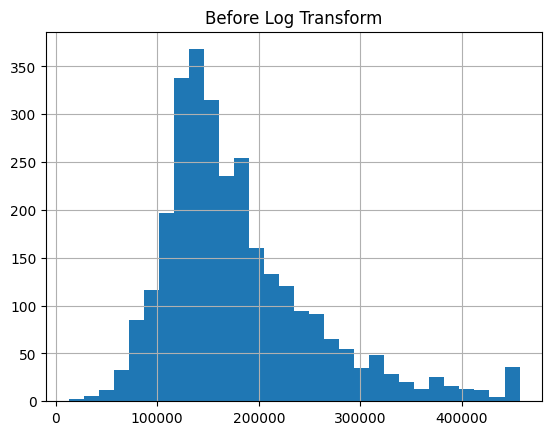

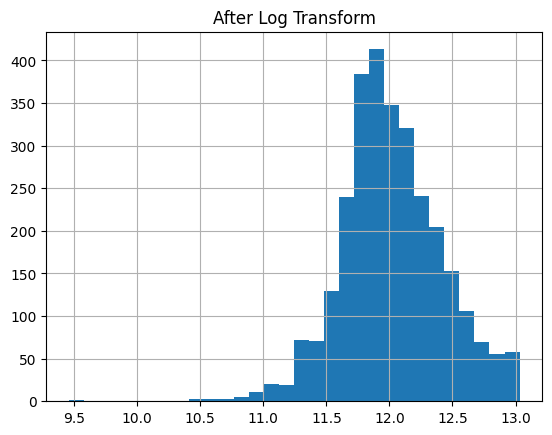

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

تم تحميل الملف بنجاحPhase 3


In [11]:
def run_phase2(df):
    df = one_hot_encode(df)
    df = ordinal_encode(df)
    df = create_domain_features(df)
    df = create_interaction_feature(df)
    df = log_transform(df)
    df = bin_feature(df)
    df = remove_redundant(df)

    train, test = scale_data(df)
    return train, test

train_final, test_final = run_phase2(df)

import os
os.makedirs("data/cleaned", exist_ok=True)
train_final.to_csv("data/cleaned/ames_features.csv", index=False)

from google.colab import files
files.download("data/cleaned/ames_features.csv")
print("تم تحميل الملف بنجاحPhase 3")